# Machine Learning Model on Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya
___
**Team**: XG BOOST BUSTERS  
**Contributors**: Cynthia Jemutai, Stephen Jilani, Charity Nduati,Joy Njeru , Chris Karagu , Sylvia  Wambui

**Project**: Phase 5 Capstone Project   
**Data Sources**: [Kenya Refugee and Asylum Population Dataset](https://www..com/)
___

### 1. Introduction

Kenya accommodates populations displaced by conflict, persecution, climate shocks, and political instability originating from across the region including Somalia, South Sudan, the Democratic Republic of Congo, Ethiopia, Burundi, and Rwanda, among 39 origin countries identified in this dataset.

Several organizations work together to support refugees in Kenya:
1. Department of Refugee Services (DRS): The Kenyan government agency responsible for refugee registration, camp management, policy implementation, and ensuring compliance with the Refugee Act of 2021.
2. United Nations High Commissioner for Refugees (UNHCR): Coordinates the overall refugee response, manages refugee registration and data, mobilizes international funding, and promotes refugee protection.
3. World Food Programme (WFP): Provides food assistance through food distribution and Cash and Voucher Assistance (CVA) programmes to improve food security.
4. Kenya Red Cross Society (KRCS): Delivers frontline humanitarian services, including emergency medical care, disaster response, water supply, family tracing, and support for new refugee arrivals at border entry points.

Together, these organizations form an integrated humanitarian system that provides protection, food, healthcare, and essential services to refugees across Kenya.

### 2. Problem Statement

Kenya hosts one of the largest refugee populations in sub-Saharan Africa, making effective humanitarian planning essential. However, resource planning is often based on current or historical population data rather than future forecasts, limiting preparedness for sudden increases in refugee arrivals.

Key challenges identified from the HDX HAPI dataset include:

1. Rapid population changes that increase demand for food, healthcare, shelter, and other essential services.
2. Diverse demographic groups with different ages, genders, and vulnerabilities that require tailored support.
3. Different population categories (e.g., refugees and asylum seekers) with distinct humanitarian needs.
4. Delays in resource deployment, making it difficult to respond quickly to population surges.
5. Limited use of historical data for forecasting despite decades of available records.

These challenges highlight the need for a machine learning-based forecasting approach to support better resource planning and decision-making for refugee assistance in Kenya.

### 3. Project Objectives

#### 3.1 Primary Objective


To design, develop, and validate a machine learning forecasting system that predicts Kenya's refugee and asylum-seeker population levels disaggregated by origin country, population group, gender, and age cohort with a forecasting horizon of 6 to 24 months, and to translate these forecasts into quantified humanitarian resource planning recommendations.

#### 3.2 Specific Objectives


1. Explore the HDX HAPI Kenya dataset to identify population trends, demographic patterns, and changes over time.
2. Create relevant features to improve forecasting performance.
3. Develop and compare forecasting models to predict refugee population trends.
4. Generate population forecasts by refugee category, age, gender, and country of origin.
5. Estimate humanitarian resource needs based on the forecasted population.
6. Evaluate model performance using standard forecasting metrics (RMSE, MAE, and MAPE).
7. Provide recommendations to support data-driven humanitarian planning and decision-making in Kenya.

### 4. Data Understanding


The dataset used for this project is the Kenya Refugee and Asylum Population Dataset, obtained from the Humanitarian Data Exchange (HDX) platform.The dataset contains historical records of displaced populations hosted in Kenya and provides detailed demographic information necessary for forecasting refugee population trends and supporting humanitarian resource planning.

The dataset covers a 25-year period from 2001 to 2025, containing 27,664 records and 15 variables. Each record represents a population observation reported for a specific period, location, population category, gender, and age group.

The dataset includes four main population groups:

1. Refugees (REF): Individuals who have been recognized as refugees and require international protection.
2. Asylum Seekers (ASY): Individuals who have applied for refugee status and are awaiting determination.
3. Host Community (HST): Members of the local population affected by refugee presence and humanitarian operations.
4. Others of Concern (OOC): Individuals who require humanitarian assistance but do not fall under the refugee or asylum seeker categories.

The main target variable for this project is:

**Population**: The recorded number of individuals within each demographic category. This variable will be used as the target for forecasting future refugee and asylum-seeker population levels.

The dataset contains demographic and geographical variables that allow population analysis at different levels:

1. reference_period_start	Beginning date of the reporting period
2. reference_period_end	End date of the reporting period
3. asylum_location_code	Country where asylum is provided
4. origin_location_code	Country of origin of displaced population
5. population_group	Refugee population category
6. gender	Gender category (male/female)
7. age_range	Age cohort category
8. min_age	Minimum age represented in the age group
9. max_age	Maximum age represented in the age group
10. population	Number of individuals recorded

The dataset is suitable for this project because it contains long-term historical observations, demographic breakdowns, and population movement patterns required for machine learning forecasting. The availability of historical trends enables the development of models capable of predicting future refugee population changes over a 6–24 month horizon.

Understanding these variables is essential for feature engineering and model development, as factors such as country of origin, population group, age distribution, gender, and historical population trends may influence future humanitarian resource requirements.

#### 4.1 Loading of Data  and relevant Libraries

In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
#load data
df = pd.read_csv("Kenya_Refugee.csv")
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020-01-01,2020-12-31


#### 4.2 Data Overview

In [4]:
#total rows and columns
df.shape

(27664, 14)

In [5]:
#list columns
df.columns.tolist()

['origin_location_code',
 'origin_has_hrp',
 'origin_in_gho',
 'asylum_location_code',
 'asylum_has_hrp',
 'asylum_in_gho',
 'population_group',
 'gender',
 'age_range',
 'min_age',
 'max_age',
 'population',
 'reference_period_start',
 'reference_period_end']

*Dataset has 27,664 rows and 15 columns*

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27664 entries, 0 to 27663
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   origin_location_code    27664 non-null  object
 1   origin_has_hrp          27664 non-null  bool  
 2   origin_in_gho           27664 non-null  bool  
 3   asylum_location_code    27664 non-null  object
 4   asylum_has_hrp          27664 non-null  bool  
 5   asylum_in_gho           27664 non-null  bool  
 6   population_group        27664 non-null  object
 7   gender                  27664 non-null  object
 8   age_range               27664 non-null  object
 9   min_age                 27664 non-null  object
 10  max_age                 27664 non-null  object
 11  population              27664 non-null  int64 
 12  reference_period_start  27664 non-null  object
 13  reference_period_end    27664 non-null  object
dtypes: bool(4), int64(1), object(9)
memory usage: 2.2+ MB


The dataset contains a combination of categorical, numerical, and date-based variables.
An assessment of missing values shows that no missing values are present across the dataset variables.

In [7]:
df.describe()

,population
count,27664.000000
mean,1409.757591
std,13881.284560
min,0.000000
25%,0.000000
50%,0.000000
75%,17.000000
max,517666.000000


The descriptive statistic show that the population variable has a highly uneven distribution, ranging from **0 to 517,666 individuals** across 27,664 observations. The mean population of approximately **1,410** compared to a median of **0** indicates that many records represent small or zero population groups, while a few observations contain very large refugee populations.

This pattern is expected in humanitarian datasets because records are highly disaggregated by country of origin, age, gender, and population group. Zero values may represent valid cases where no individuals were recorded for a specific category and period, rather than missing data. Therefore, they will be retained and considered during modeling. The variation in population sizes highlights the need for machine learning approaches capable of capturing both stable population trends and sudden displacement changes.


### 5. Data Cleaning

Data cleaning was conducted to improve data quality and ensure that the dataset was suitable for exploratory analysis and machine learning forecasting. The cleaning process focused on selecting relevant records, removing duplicate representations, validating data completeness, correcting data types, and investigating unusual population values.

#### 5.1 Filtering relevant records

In [8]:
#filtering the data set to have only data  for refugees who took  assylum in kenya
df = df[df['asylum_location_code']=='KEN']
df

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020-01-01,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27659,ZWE,False,False,KEN,False,True,REF,m,12-17,12,17,0,2025-01-01,2025-12-31
27660,ZWE,False,False,KEN,False,True,REF,m,18-59,18,59,0,2025-01-01,2025-12-31
27661,ZWE,False,False,KEN,False,True,REF,m,60+,60,None,0,2025-01-01,2025-12-31
27662,ZWE,False,False,KEN,False,True,REF,m,all,None,None,8,2025-01-01,2025-12-31


The dataset was first filtered to include only records where the asylum location was Kenya. This ensured that the analysis focused specifically on refugee and asylum populations hosted within Kenya, aligning with the project's objective of forecasting humanitarian needs in the country.

#### 5.2 Checking Missing Values and Duplicates

The dataset was assessed for missing values and duplicate records. The analysis showed that there were no missing values across the variables, indicating that the dataset was complete and did not require missing value imputation. Duplicate records were also checked to ensure that repeated observations would not affect population estimates or model performance.

In [9]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\n')
#duplicate
print('Duplicate :', df.duplicated().sum())

Missing values per column:
origin_location_code      0
origin_has_hrp            0
origin_in_gho             0
asylum_location_code      0
asylum_has_hrp            0
asylum_in_gho             0
population_group          0
gender                    0
age_range                 0
min_age                   0
max_age                   0
population                0
reference_period_start    0
reference_period_end      0
dtype: int64


Duplicate : 0


#### 5.3 Handling Aggregated Categories

The dataset contained aggregated categories represented as "all" in the gender and age range variables. These categories were reviewed to determine whether they would affect population analysis.




In [10]:
# Display the unique gender categories in the dataset
df['gender'].unique()

array(['f', 'm', 'all'], dtype=object)

In [11]:
#we noticed that the all column was an addition of the males and female which would lead to duplication
#drop 'all' on gender
df = df[df['gender'] != 'all']
print(df['gender'].unique())

['f' 'm']


The "all" gender category was removed because it represents the combined total of male and female populations. Keeping this category alongside the individual male and female records would result in duplicate population counts and inflate population estimates.

In [12]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+', 'all'], dtype=object)

In [13]:
#Checking the frequency distribution of the age range category
df['age_range'].value_counts()

all      1708
60+      1708
0-4      1708
18-59    1708
5-11     1708
12-17    1708
Name: age_range, dtype: int64

The distribution of the age range variable was examined to understand the representation of each demographic group. The dataset contained five defined age cohorts (0–4, 5–11, 12–17, 18–59, and 60+) as well as an aggregated "all" category. This check was important to identify the structure of the age variable and determine how the aggregated category should be handled during data preparation.

In [14]:
#drop 'all' on age range

df = df[df['age_range'] != 'all']
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+'], dtype=object)

The "all" category was removed because it represents an aggregated population total rather than a distinct age cohort. Including it alongside individual age groups could introduce overlapping population information and affect age-specific analysis and forecasting.

In [15]:
# Checking min_age and max_age
df[['min_age','max_age']].head(10)

,min_age,max_age
0,0,4
1,5,11
2,12,17
3,18,59
4,60,None
6,0,4
7,5,11
8,12,17
9,18,59
10,60,None


Following the removal of the "all" category, the age boundary variables were checked to verify that all remaining age groups had valid age ranges. This confirmed that the dataset was ready for age specific analysis and modeling.

The 60+ category was not assigned an artificial maximum age because it represents an open-ended age group. Introducing a fixed upper limit would create an unsupported assumption and could affect the interpretation of elderly population estimates.

#### 5.4 Validating Population Values

The population variable was examined to understand its distribution and identify potential data quality issues. The analysis showed that population values ranged from zero to very large population counts. A significant number of records contained zero population values.

Further investigation showed that zero values occurred across different: population groups,gender categories,and age ranges.



In [16]:
#checking distribution
df['population'].describe()

count      8540.000000
mean       1384.064988
std        6681.813404
min           0.000000
25%           0.000000
50%           6.000000
75%         156.000000
max      115273.000000
Name: population, dtype: float64

In [17]:
# Display the unique population group categories in the dataset
df['population_group'].unique()

array(['ASY', 'REF', 'HST', 'OOC'], dtype=object)

In [18]:
# Examine the distribution of zero population values across population groups
df[df['population'] == 0]['population_group'].value_counts()

ASY    2084
REF    1498
OOC     140
HST      60
Name: population_group, dtype: int64

In [19]:
# Examine the distribution of zero population values across gender categories
df[df['population'] == 0]['gender'].value_counts()

f    1971
m    1811
Name: gender, dtype: int64

In [20]:
# Examine the distribution of zero population values across age groups
df[df['population'] == 0]['age_range'].value_counts()

60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
Name: age_range, dtype: int64

In [21]:
# investigating the zeros
(df['population'] == 0).sum()

3782

In [22]:
(df['population'] == 0).mean()*100

44.285714285714285

Approximately 44% of observations have zero population counts. This is expected in a highly disaggregated refugee dataset where many demographic combinations may have no recorded individuals during a reporting period. Since zeros occur across multiple groups and are not associated with a specific data quality issue, they were retained as valid observations.

Retaining zero values allows the forecasting model to learn both population growth patterns and periods of low or absent population presence, improving its ability to support realistic humanitarian planning.

#### 5.5 Converting Date Variables

In [23]:
#Converting the reference period start and reference period end from string to date
df['reference_period_start']= pd.to_datetime(df['reference_period_start'])
df['reference_period_end']= pd.to_datetime(df['reference_period_end'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8540 entries, 0 to 27661
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   origin_location_code    8540 non-null   object        
 1   origin_has_hrp          8540 non-null   bool          
 2   origin_in_gho           8540 non-null   bool          
 3   asylum_location_code    8540 non-null   object        
 4   asylum_has_hrp          8540 non-null   bool          
 5   asylum_in_gho           8540 non-null   bool          
 6   population_group        8540 non-null   object        
 7   gender                  8540 non-null   object        
 8   age_range               8540 non-null   object        
 9   min_age                 8540 non-null   object        
 10  max_age                 8540 non-null   object        
 11  population              8540 non-null   int64         
 12  reference_period_start  8540 non-null   datetim

In [24]:
# converting the refrence start period and dropping the end period to creat the year column
df['year'] = df['reference_period_start'].dt.year
df.drop(columns=['reference_period_start', 'reference_period_end'], inplace=True)



#### 5.6 Handling Extreme Population Values

The population distribution was reviewed using descriptive statistics and boxplots.

In [25]:
#checking distribution
df['population'].describe()

count      8540.000000
mean       1384.064988
std        6681.813404
min           0.000000
25%           0.000000
50%           6.000000
75%         156.000000
max      115273.000000
Name: population, dtype: float64

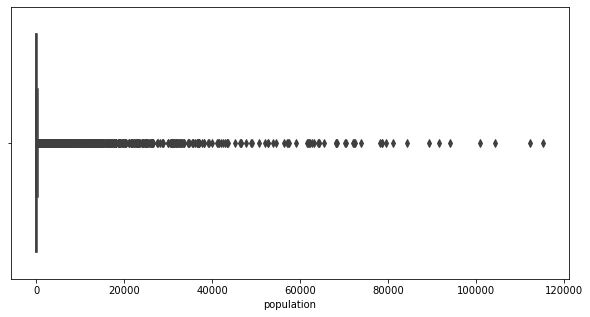

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['population'])
plt.show()

The variable showed a highly right-skewed distribution, with a small number of very large population counts. These extreme values were retained because they represent genuine large refugee populations and are important for humanitarian resource planning. Removing them would reduce the model's ability to capture large-scale displacement events.

#### 5.7 Final Validation of data

In [27]:
# Final inspection of the data
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020


In [28]:
df.shape

(8540, 13)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8540 entries, 0 to 27661
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   origin_location_code  8540 non-null   object
 1   origin_has_hrp        8540 non-null   bool  
 2   origin_in_gho         8540 non-null   bool  
 3   asylum_location_code  8540 non-null   object
 4   asylum_has_hrp        8540 non-null   bool  
 5   asylum_in_gho         8540 non-null   bool  
 6   population_group      8540 non-null   object
 7   gender                8540 non-null   object
 8   age_range             8540 non-null   object
 9   min_age               8540 non-null   object
 10  max_age               8540 non-null   object
 11  population            8540 non-null   int64 
 12  year                  8540 non-null   int64 
dtypes: bool(4), int64(2), object(7)
memory usage: 700.5+ KB


Zero population values are observed across all age groups, with the largest number occurring among children aged 0–4 years. Since the zeros are spread throughout the age categories rather than concentrated in a single group, they are more likely to represent valid observations than systematic data errors. The zero values will be retained because there is no evidence that they are caused by age-specific reporting problems.

**6. EXPLORATORY DATA ANALYSIS**

**UNIVARIATE ANALYSIS**

The variables in the dataset all are all categorical variables and are repeated throughout the dataset. They therefore appear the same number of times thtoughut the dataset. This applies to all the varianles except the population column. The best approach to EDA is bivariate analysis.

<AxesSubplot:ylabel='gender'>

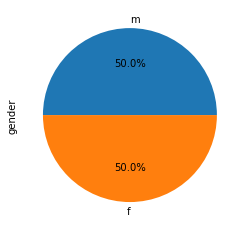

In [30]:
#Plotting a pie chart to show the distribution of gender categories

df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

The pie chart showsthat there is a balanced disttribution of both genders as represented in the dataset.

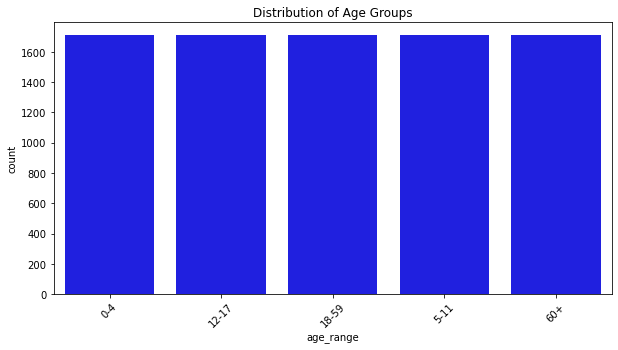

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="age_range",
    order=sorted(df["age_range"].unique()),
    color='blue'
)

plt.title("Distribution of Age Groups")
plt.xticks(rotation=45)
plt.show()

The graph shows that there is a balanced disttribution of all the age ranges as represented in the dataset.

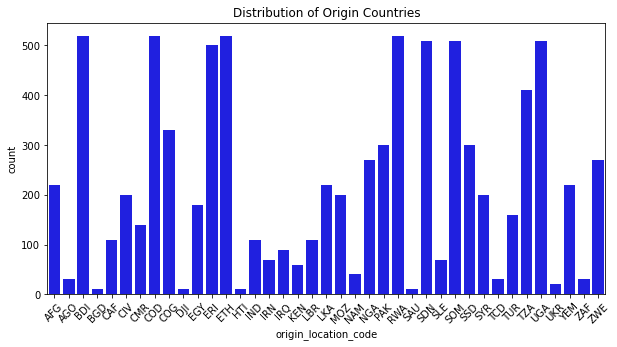

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="origin_location_code",
    order=sorted(df["origin_location_code"].unique()),
    color='blue'
)

plt.title("Distribution of Origin Countries")
plt.xticks(rotation=45)
plt.show()

The plot shows the representation of different refugee origin countries within the dataset. The number of records varies across countries due to differences in reporting frequency and duration of refugee presence. This provides an understanding of data coverage across origin countries before further population analysis.

In [33]:
#Plotting a pie chart




**BIVARIATE ANALYSIS**

<function matplotlib.pyplot.show(close=None, block=None)>

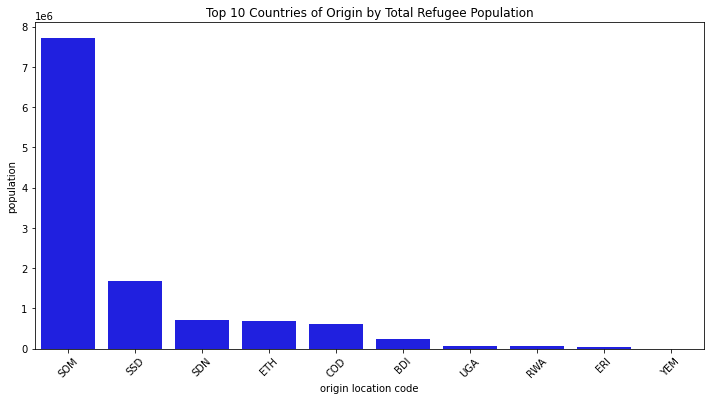

In [34]:
#A graph of countries against the population. This is to show where most refugees have come from across the dataset.

#Grouping origin location codes and finding the total population for each one of them.
country_population = (
    df.groupby('origin_location_code')['population']
        .sum()
        .reset_index()
)

top_10 = (
    country_population
    .sort_values(by = 'population', ascending = False)
    .head(10)
)

#Plotting the bar based on the grouped data above.
plt.figure(figsize=(12,6))

sns.barplot(data=top_10, x= 'origin_location_code', y = 'population', color='blue')

plt.title("Top 10 Countries of Origin by Total Refugee Population")
plt.xlabel("origin location code")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show


**Interepretation of the origin location vs population graph**

Based on the above bar chart, the maximum refugees that end up in Kenya are from Somalia,followed by Southsudan by a very big distance followed by Sudan,Ethiopia and Congo. This is to say that Kenyan refugees comes from the immediate neignbbouring countries rather than countries that involve crossing multiple borders to get to Kenya.

In [35]:
#Running the dataframe for visibility
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020


<function matplotlib.pyplot.show(close=None, block=None)>

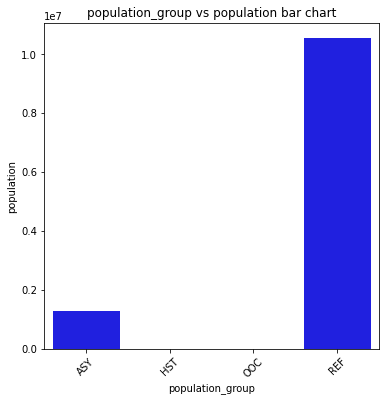

In [36]:
#The plot below is for population group which is either asylum or refugee etc against population

#creating a variable which groups the data by population group and computes the total population of each.
population_g_population = (
    df.groupby('population_group')['population']
        .sum()
        .reset_index()
)

#Plotting the bar graph
plt.figure(figsize=(6,6))

sns.barplot(data=population_g_population, x= 'population_group', y = 'population', color='blue')

plt.title("population_group vs population bar chart")
plt.xlabel("population_group")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show

**Interepretation of the origin location vs population graph**

The bar graph stresses on 2 categories which is Refugee and Asylum. With refugees being the people who receive their official status of being refugees while int heir origin country while asylum seekers receive their official status while already in the destination country.

However it is, the refugees are the majority 10-foled. This is a good indicator for humanitarian organizations in resource planning as most individuals are already identified while they are still in their country of origin. This gives lead time before they arrive in the destination country.

The other 2 categories are for Host Community and Others of Concern. These form a very negligible part of the data and aren't expected to have much impact on the final models.

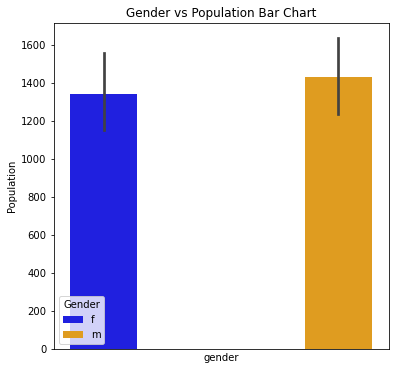

In [37]:
plt.figure(figsize=(6,6))

sns.barplot(
    data=df,
    x='gender',
    y='population',
    hue='gender',
    palette={'m': 'orange', 'f': 'blue'}
)

plt.title("Gender vs Population Bar Chart")
plt.xticks([])
plt.ylabel("Population")
plt.legend(title='Gender',)
plt.show()

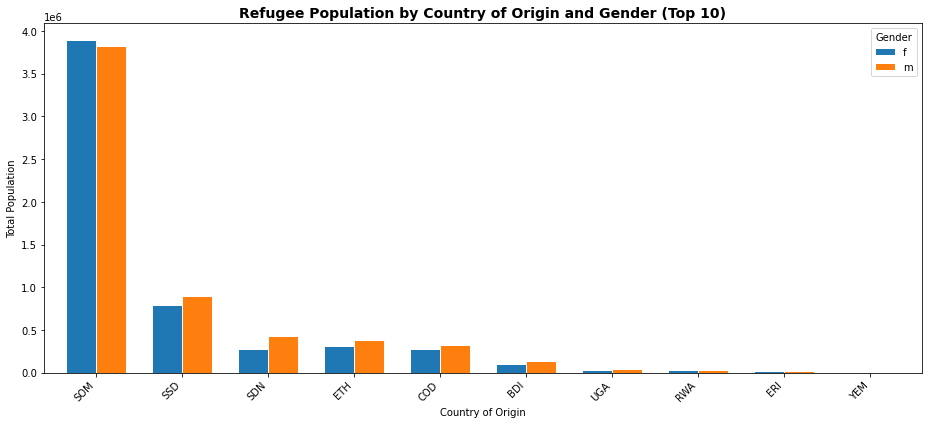

In [38]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

**Interepretation of the graph**

The nearly equal proportion of men and women suggests that displacement from the main countries of origin affects both genders at similar rates. For humanitarian planners, this indicates that gender-responsive interventions should receive balanced funding and staffing.

<function matplotlib.pyplot.show(close=None, block=None)>

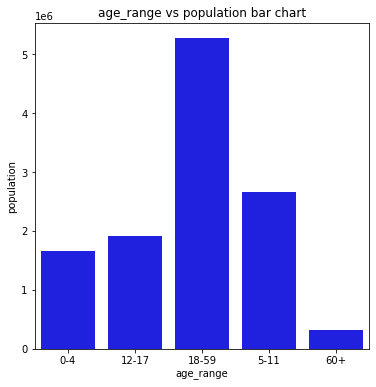

In [39]:
#Plotting a baer chart for age range against population

#Grouping age range and getting the total of population for each category
age_range_population = (
    df.groupby('age_range')['population']
        .sum()
        .reset_index()
)

#Plotting the figure

plt.figure(figsize=(6,6))

sns.barplot(data=age_range_population, x= 'age_range', y = 'population', color='blue')

plt.title("age_range vs population bar chart")
plt.xlabel("age_range")
plt.ylabel("population")
#plt.xticks(rotation=45)
plt.show

**Interepretation of the graph**

The 18–59 age group forms the largest share of the population due to its broad age range. Children (0–17) also make up a significant proportion, highlighting the need for education, child protection, and nutrition services. Although the 60+ group is the smallest, it has the greatest healthcare needs. The UNHCR Age, Gender and Diversity (AGD) framework emphasizes planning based on age- and gender-disaggregated data to meet these diverse needs.


<function matplotlib.pyplot.show(close=None, block=None)>

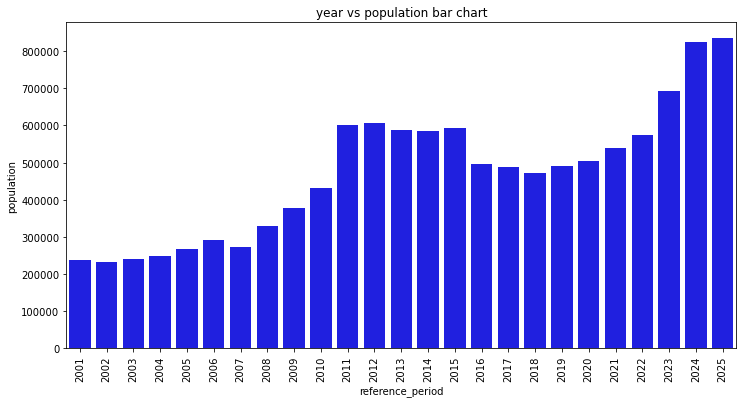

In [40]:
#Plotting a bar chart for the reference years against population

#Grouping the data based on years and then finding the sum of each.
period_population = (
    df.groupby('year')['population']
        .sum()
        .reset_index()
)

#Plotting thebar

plt.figure(figsize=(12,6))

sns.barplot(data=period_population, x= 'year', y = 'population', color='blue')

plt.title("year vs population bar chart")
plt.xlabel("reference_period")
plt.ylabel("population")
plt.xticks(rotation=90)
plt.show

**Interepretation of the graph**

The trend shows three phases: rapid growth (2001–2011), a period of stability and slight decline (2012–2019), and renewed growth from 2020 onward due to escalating regional conflicts. This non-linear pattern demonstrates that simple trend-based forecasting is inadequate, highlighting the need for machine learning models that can better capture complex population dynamics.


**MULTIVARIATE ANALYSIS**

Multivariate analysis examines relationships among three or more variables simultaneously. This helps uncover complex demographic patterns that may not be visible through univariate or bivariate analysis.

For humanitarian organizations, understanding how age, gender, country of origin, and population interact is essential for effective resource planning and forecasting.

The four analyses below move from demographic composition to country-gender dynamics to origin dominance to temporal trends, building
a complete picture of Kenya's refugee population structure.

**Age Range, Gender and Population**

### Business Question

How is the refugee population distributed across different age groups and genders?

Understanding the demographic composition of refugee populations can help humanitarian agencies allocate healthcare, education, protection services, and livelihood programs more effectively.

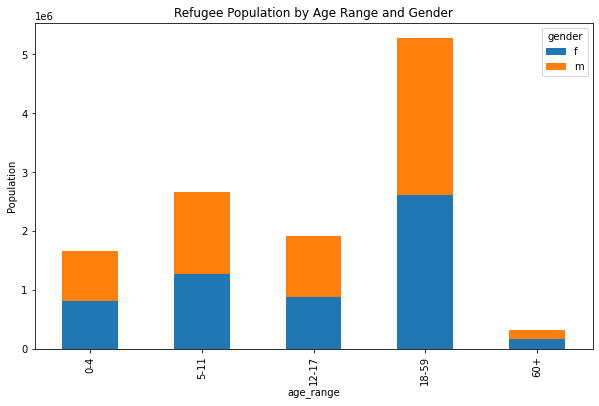

In [41]:
age_gender = pd.pivot_table(
    df,
    values='population',
    index='age_range',
    columns='gender',
    aggfunc='sum'
)
age_order = ['0-4', '5-11', '12-17', '18-59', '60+']
age_gender = age_gender.reindex(age_order)
age_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Refugee Population by Age Range and Gender')
plt.ylabel('Population')
plt.show()

### Observation

The 18–59 working-age group is the largest demographic for both males and females, reflecting that displacement is primarily experienced by adults escaping conflict or persecution. Children aged 0–17 also make up a considerable share of the population, while those aged 60 and above represent the smallest group. Gender distribution remains relatively balanced across all age categories, with no significant dominance by either males or females.


### Business Insight

The demographic profile has important planning implications. The large 18–59 population drives demand for livelihood, skills training, and adult mental health services. The sizeable 0–17 population requires continued investment in education, nutrition, and child protection. Although the 60+ group is small, it has greater healthcare needs, consistent with the UNHCR Age, Gender and Diversity (AGD) framework. The balanced gender distribution also calls for equitable provision of gender-responsive services, including reproductive healthcare, GBV prevention, and psychosocial support.


**Country of Origin, Gender and Population**

### Business Question

How does gender composition vary across top refugee-producing countries?

Understanding gender patterns across countries of origin helps humanitarian agencies identify vulnerable populations and design targeted interventions.

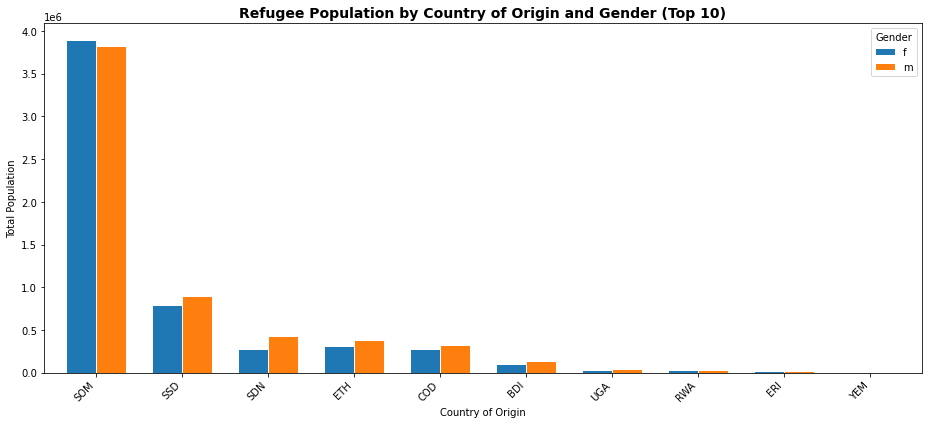

In [42]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### Observation

Somalia (SOM) is the largest source country by far, followed by South Sudan (SSD), DRC, Ethiopia (ETH), Sudan (SDN), and Burundi (BDI). Gender distribution is generally balanced, with Somalia showing a slight female majority, while Ethiopia and Eritrea display more balanced or slightly male-leaning patterns, reflecting differences in displacement dynamics.


### Business Insight

The high concentration of refugees from Somalia and South Sudan means that forecasting these two populations is critical to the effectiveness of the planning system. Inaccuracies for these countries would have a greater impact on resource allocation than errors involving smaller origin groups. Gender patterns also influence programme needs: female-majority populations may require increased support for female-headed households, including protection, shelter, and livelihood assistance, while balanced or male-skewed populations may reflect different migration patterns requiring tailored psychosocial and economic support. Countries experiencing recent population growth should be closely monitored for changing gender trends that may affect future planning.



**Top 10 Countries of Origin vs Relative Population Share (Treemap)**

### Business Question

Which origin countries contribute the largest total refugee populations
to Kenya, and how stark is the concentration among the top contributors
relative to the rest?

In [2]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


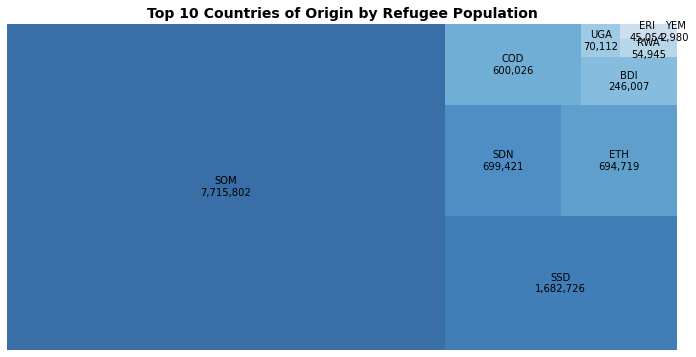

In [44]:
import squarify

# Top 10 countries by population
country_pop = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
)

# Labels
labels = [f"{c}\n{v:,.0f}" for c, v in country_pop.items()]

plt.figure(figsize=(12, 6))

squarify.plot(
    sizes=country_pop.values,
    label=labels,
    color=plt.cm.Blues(range(230, 30, -20)),
    alpha=0.8
)

plt.title('Top 10 Countries of Origin by Refugee Population',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

### Observation

The treemap highlights the strong concentration of refugee populations among a few origin countries. Somalia represents the largest share by far, followed by South Sudan, while DRC, Ethiopia, Sudan, and Burundi contribute smaller but significant proportions. The remaining top 10 countries account for only a limited share, and the exclusion of around 29 other origin countries further demonstrates the dominance of the largest sources.
.

### Business Insight

The concentration of refugee populations in a few origin countries has important implications for ML forecasting. High-volume countries such as Somalia, South Sudan, DRC, Ethiopia, and Sudan should have separate models to improve accuracy, while smaller groups are better suited to simpler pooled approaches to reduce overfitting. Since Somalia has the greatest impact on overall estimates, accurate forecasting is essential. Emerging instability in mid-sized sources like Ethiopia and DRC also requires ongoing monitoring, as their displacement trends may change significantly over the next few years.



**Population Group by Age group**

How are the four population groups (REF, ASY, HST, OOC) distributed across age cohorts, and what does this imply for group-specific humanitarian programming?

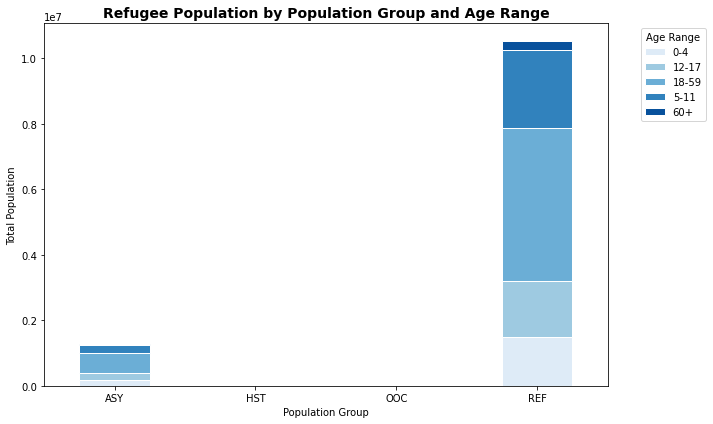

In [45]:
pop_group_age = pd.pivot_table(
    df,
    values='population',
    index='population_group',
    columns='age_range',
    aggfunc='sum'
)

pop_group_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#DEEBF7', '#9ECAE1', '#6BAED6', '#3182BD', '#08519C'],
    edgecolor='white'
)

plt.title('Refugee Population by Population Group and Age Range',
          fontsize=14, fontweight='bold')
plt.ylabel('Total Population')
plt.xlabel('Population Group')
plt.xticks(rotation=0)
plt.legend(title='Age Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Year of Assylum, Country of Origin and Population**


How have refugee population trends evolved over time for the five largest
origin countries?

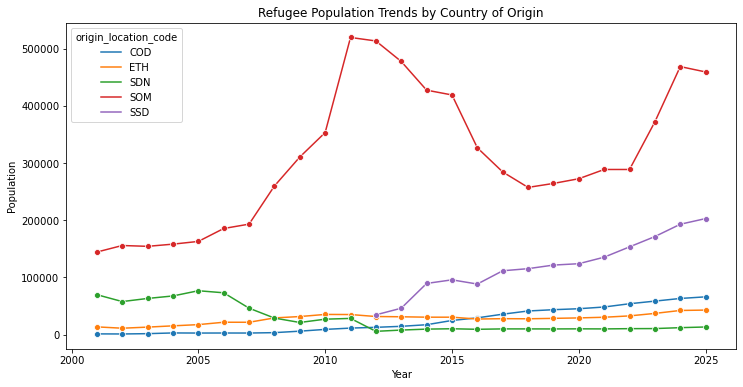

In [46]:

top_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(5)
      .index
)

year_country = (
    df[df['origin_location_code'].isin(top_countries)]
      .groupby(['year','origin_location_code'])['population']
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_country,
    x='year',
    y='population',
    hue='origin_location_code',
    marker='o'
)

plt.title('Refugee Population Trends by Country of Origin')
plt.xlabel('Year')
plt.ylabel('Population')

plt.show()

### Observation

Somalia (SOM) remains the largest source population from 2001–2025, with major increases around 2011, a slight decline during the mid-2010s, and renewed growth after 2020. South Sudan (SSD) experienced a sharp rise from 2013 following the civil war, becoming the second-largest origin group. Ethiopia (ETH) and DRC (COD) show persistent but smaller populations, with Ethiopia increasing after 2020 due to the Tigray conflict, while Sudan (SDN) shows a steady recent rise.


### Business Insight

The trends highlight three key implications for the forecasting system. First, refugee movements are driven by major events rather than steady patterns, requiring ML models to capture sudden changes and incorporate external conflict indicators. Second, prolonged displacement is common, meaning models must account for stable long-term populations alongside crisis-related increases. Third, simultaneous growth across multiple countries after 2020 suggests regional instability, making multi-country surge scenarios essential for effective planning.


# Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into refugee population dynamics in Kenya.

Key findings include:

- Refugee populations are unevenly distributed, with a few demographic groups and countries contributing the largest populations.
- The working-age population (18–59 years) forms the largest age segment among refugees hosted in Kenya.
- Both male and female refugees contribute significantly to the overall population.
- Refugee populations originate from multiple countries, although a small number of countries account for the majority of refugee inflows.
- Population trends vary over time, highlighting the dynamic nature of displacement and the importance of predictive analytics.
- Demographic patterns differ across age groups, genders, and countries of origin, suggesting varying humanitarian needs.

These findings provide a strong foundation for feature engineering and predictive modeling. The identified demographic and temporal patterns will support the development of machine learning models capable of forecasting refugee population changes and improving humanitarian resource planning in Kenya.

## 6.Preprocessing

In [47]:
# importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix,f1_score)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor



 Reproducing a cleaned dataset

In [48]:
#converting categorical data to numerical  data
df['origin_has_hrp'] = df['origin_has_hrp'].astype(int)
df['origin_in_gho'] = df['origin_in_gho'].astype(int)

In [49]:
df_final = df.copy()
# define feature and target variable
X = df_final.drop(columns=['population','asylum_has_hrp','asylum_in_gho','min_age','max_age'])
y = np.log1p(df_final['population'])


Since this is a time series forecasting problem, the data was split chronologically rather than randomly. Earlier observations were used for training, while more recent observations were reserved for testing. This prevents information from future periods leaking into the training data and provides a realistic evaluation of the model's forecasting performance.

Having a larger train set means that the model has enough data to learn underlying patterns and still maintain enough data to test the validation of the model in real world situations. This avoids overfitting and reducing skewed test metrics.

# 6.1 corrected preprocessing (leak-free pipeline + column transformer)

In [50]:
categorical_cols = ['origin_location_code', 'population_group', 'gender', 'age_range']
base_num_cols = ['origin_has_hrp', 'origin_in_gho', 'year']

X = df[categorical_cols + base_num_cols].copy()
y = df['population'].copy()

# Chronological split for a time-series-style evaluation
train_mask = df['year'] <= 2022
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(X_train.shape, X_test.shape)

(7060, 7) (1480, 7)


In [51]:
def build_pipeline(model, categorical_cols):
    preprocess = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
        remainder='passthrough'
    )
    return Pipeline([('prep', preprocess), ('model', model)])

def evaluate(pipe, X_tr, y_tr, X_te, y_te, name):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    print(f"{name:35s} MAE: {mae:9.2f}   RMSE: {rmse:9.2f}   R2: {r2:7.3f}")
    return pred

In [52]:
from sklearn.linear_model import LinearRegression

lr_pipe = build_pipeline(
    LinearRegression(),
    categorical_cols
)

y_test_pred=evaluate(
    lr_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Linear Regression"
)

Linear Regression                   MAE:   2174.58   RMSE:   5005.01   R2:   0.429


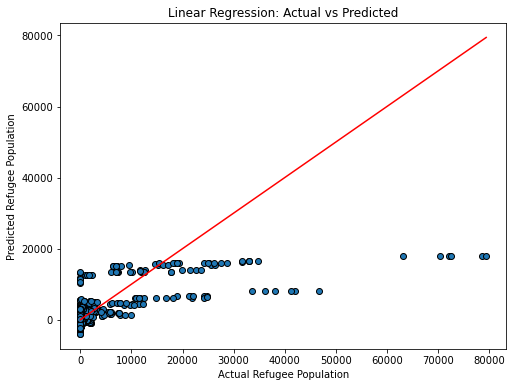

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred,edgecolors='k')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")


plt.xlabel("Actual Refugee Population")
plt.ylabel("Predicted Refugee Population")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

### Correlation Heatmap of Numerical Features

numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [54]:
rf_pipe = build_pipeline(
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    categorical_cols
)

rf_pred = evaluate(
    rf_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest                       MAE:    466.63   RMSE:   2285.70   R2:   0.881


In [55]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

param_dist = {
    'model__n_estimators': [200, 300, 500, 800],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2']
}

rf_pipe = build_pipeline(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    categorical_cols
)

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'model__n_estimators': 800, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
-2183.7386809944433


In [56]:
best_rf = search.best_estimator_

pred = best_rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 564.7993088710602
RMSE: 2429.439779447554
R²  : 0.8654128257855803


In [57]:
print("=== Baseline models (correctly aligned, no leakage, NO lag features) ===")
pred_lr = evaluate(build_pipeline(LinearRegression(), categorical_cols), X_train, y_train, X_test, y_test, "Linear Regression")
# pred_dt = evaluate(build_pipeline(DecisionTreeRegressor(random_state=42), categorical_cols), X_train, y_train, X_test, y_test, "Decision Tree")
pred = evaluate(build_pipeline(RandomForestRegressor(random_state=42, n_estimators=800, n_jobs=-1), categorical_cols), X_train, y_train, X_test, y_test, "Random Forest")

=== Baseline models (correctly aligned, no leakage, NO lag features) ===
Linear Regression                   MAE:   2174.58   RMSE:   5005.01   R2:   0.429
Random Forest                       MAE:    466.30   RMSE:   2285.21   R2:   0.881


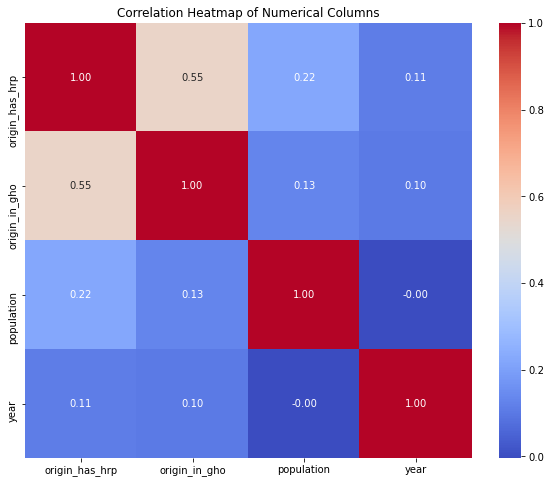

In [58]:
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

The correlation analysis showed weak linear relationships between the numerical predictors and refugee population. For example, year and population had almost zero correlation, while origin_has_hrp and origin_in_gho showed weak positive correlations. This suggests that refugee population dynamics may involve nonlinear relationships and interactions among multiple factors rather than simple linear associations

Transformer model

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

print("Feature scaling completed.")

Feature scaling completed.
